# Tutorial paso a paso: uso del operador directo `MT3D`

**Proyecto 045-2025 — P8091**

Este cuaderno explica, **desde cero y paso a paso**, cómo se usa el operador de modelamiento
directo magnetotelúrico (MT) `Forward/MT3D.py`, cuya función pública es:

```python
from Forward.MT3D import compute_mt_impedance_tipper

Z, T = compute_mt_impedance_tipper(mesh, sigma, receivers, frequencies, mu=None)
```

Está pensado para alguien que **nunca ha usado el operador**. Cada paso responde tres preguntas:
*¿qué se hace?*, *¿por qué se hace así?* y *¿cómo se verifica que quedó bien?*

---

## Qué vamos a hacer

| Paso | Contenido |
|:--:|---|
| 0 | Teoría mínima: qué resuelve el operador |
| 1 | Importar el operador |
| 2 | Construir la malla 3D (`TensorMesh`) |
| 3 | Definir el modelo de conductividad `sigma` |
| 4 | Definir receptores y frecuencias |
| 5 | Verificar el diseño de la malla (skin depth) |
| 6 | **Ejecutar el operador** (caso semiespacio) |
| 7 | Entender la forma de las salidas `Z` y `T` |
| 8 | Validar contra la solución analítica 1D |
| 9 | Un caso realmente 3D (bloque conductor) |
| 10 | Qué hace el operador por dentro, línea por línea |
| 11 | Guardar / cargar resultados y errores frecuentes |

## Requisitos: paquetes necesarios

| Paquete | Para qué se usa aquí |
|---|---|
| `numpy` | arreglos y álgebra básica |
| `scipy` | matrices dispersas y factorización LU del sistema lineal |
| `discretize` | malla 3D (`TensorMesh`) y operadores de volúmenes finitos (`edge_curl`, productos internos, interpolación) |
| `matplotlib` | figuras |
| `geoana` | lo importa `Forward/utils.py` (kernels de prisma para gravimetría/magnetometría) |
| `torch` | lo importa `Forward/utils.py` (utilidades de gravimetría/magnetometría) |

El operador `MT3D` en sí solo necesita `numpy`, `scipy` y `discretize`. Pero como también importa
`Forward.utils` (de donde salen `apparent_resistivity` y `phase_deg`), **`geoana` y `torch` tienen
que estar instalados igual**, aunque este tutorial no los use directamente.

Instalación en un entorno limpio:

```bash
# con conda (recomendado)
conda create -n mt3d python=3.11
conda activate mt3d
conda install -c conda-forge numpy scipy discretize matplotlib geoana pytorch

# o con pip
pip install numpy scipy discretize matplotlib geoana torch
```

`simpeg` **no** hace falta para este tutorial (solo para los cuadernos de comparación en
`Examples/Modelling/Toys/MT_Toy6/`).

Las versiones con las que se ejecutó este cuaderno aparecen en la siguiente celda.

### Comprueba tu entorno antes de empezar

Ejecuta la celda siguiente: lista los paquetes requeridos, su versión, y te dice exactamente
cuáles faltan y cómo instalarlos.

In [ ]:
# Si te falta algún paquete, descomenta la línea que corresponda y ejecútala UNA vez.
# Después reinicia el kernel.

# %pip install numpy scipy discretize matplotlib geoana torch
# %conda install -c conda-forge numpy scipy discretize matplotlib geoana pytorch

In [1]:
# ------------------------------------------------------------------
# Verificación del entorno: ¿están todos los paquetes necesarios?
# ------------------------------------------------------------------
import importlib
import sys

requeridos = {
    "numpy":      "arreglos y álgebra básica",
    "scipy":      "matrices dispersas y factorización LU del sistema",
    "discretize": "malla 3D (TensorMesh) y operadores de volúmenes finitos",
    "matplotlib": "figuras",
    "geoana":     "lo importa Forward/utils.py (kernels de gravimetría/magnetometría)",
    "torch":      "lo importa Forward/utils.py (utilidades de gravimetría/magnetometría)",
}

print("Python", sys.version.split()[0])
print()

faltantes = []
for paquete, motivo in requeridos.items():
    try:
        mod = importlib.import_module(paquete)
        version = getattr(mod, "__version__", "?")
        print(f"  [ok]    {paquete:<12} {version:<14} {motivo}")
    except ImportError:
        faltantes.append(paquete)
        print(f"  [FALTA] {paquete:<12} {'':<14} {motivo}")

print()
if faltantes:
    print("Faltan paquetes. Instálalos con:")
    print("    pip install " + " ".join(faltantes))
else:
    print("Entorno completo: el tutorial puede ejecutarse de principio a fin.")

Python 3.11.15

  [ok]    numpy        1.26.4         arreglos y álgebra básica
  [ok]    scipy        1.14.1         matrices dispersas y factorización LU del sistema
  [ok]    discretize   0.11.1         malla 3D (TensorMesh) y operadores de volúmenes finitos
  [ok]    matplotlib   3.10.0         figuras
  [ok]    geoana       0.7.2          lo importa Forward/utils.py (kernels de gravimetría/magnetometría)
  [ok]    torch        2.11.0+cu128   lo importa Forward/utils.py (utilidades de gravimetría/magnetometría)

Entorno completo: el tutorial puede ejecutarse de principio a fin.


---

# Paso 0 — Teoría mínima: ¿qué resuelve `MT3D`?

## 0.1 El problema físico

En magnetotelúrica se ilumina la Tierra con una **onda plana** electromagnética natural que llega
desde arriba. A la frecuencia $f$ (con $\omega = 2\pi f$) y despreciando corrientes de
desplazamiento (aproximación cuasi-estática), el campo eléctrico $\mathbf{E}$ cumple la
**ecuación curl–curl**:

$$\nabla \times \left( \mu^{-1} \nabla \times \mathbf{E} \right) + i\,\omega\,\sigma\,\mathbf{E} \;=\; 0$$

donde $\sigma(\mathbf{r})$ es la conductividad eléctrica \[S/m\] y $\mu$ la permeabilidad magnética
\[H/m\].

## 0.2 Formulación de campo secundario

Resolver esa ecuación directamente es delicado porque la fuente está "en el infinito".
`MT3D` usa el truco estándar (el mismo de SimPEG): separar el campo en

$$\mathbf{E} = \mathbf{E}_p + \mathbf{E}_s$$

- $\mathbf{E}_p$ (**primario**): solución analítica de onda plana para un **semiespacio homogéneo**
  de conductividad de referencia $\sigma_b$. En el código es
  $E_p(z) = e^{k z}$ con $k = (1+i)\sqrt{\omega \mu_0 \sigma_b / 2}$.
- $\mathbf{E}_s$ (**secundario**): la parte que el modelo real "añade" respecto al semiespacio.

Sustituyendo, el secundario satisface el mismo operador pero con una **fuente** que solo vive donde
el modelo se aparta del semiespacio de referencia:

$$\underbrace{\left(\mathbf{C}^{T}\mathbf{M}_{\mu^{-1}}\mathbf{C} + i\omega \mathbf{M}_{\sigma}\right)}_{\mathbf{A}}\;\mathbf{e}_s \;=\; -\,i\,\omega\,\mathbf{M}_{\Delta\sigma}\,\mathbf{e}_p,
\qquad \Delta\sigma = \sigma - \sigma_b$$

Esto es exactamente lo que se ve en el código del operador.

## 0.3 Las dos polarizaciones

Una sola onda plana no basta: el tensor de impedancias tiene 4 componentes. Por eso el operador
resuelve **dos veces** por frecuencia:

- **Polarización Ex**: onda plana con $E$ en la dirección $x$.
- **Polarización Ey**: onda plana con $E$ en la dirección $y$.

Ambas comparten la **misma matriz $\mathbf{A}$**, así que la factorización LU se calcula una sola
vez por frecuencia y se reutiliza (por eso agregar polarizaciones o receptores es barato, pero
agregar frecuencias es caro).

## 0.4 De los campos a las respuestas MT

Con $\mathbf{E}$ ya resuelto, el campo magnético sale de la ley de Faraday:

$$\mathbf{B} = -\frac{1}{i\omega}\nabla\times\mathbf{E}, \qquad \mathbf{H} = \mathbf{B}/\mu$$

y las respuestas observables son

$$\begin{pmatrix} E_x \\ E_y \end{pmatrix} = \begin{pmatrix} Z_{xx} & Z_{xy} \\ Z_{yx} & Z_{yy}\end{pmatrix}\begin{pmatrix} H_x \\ H_y \end{pmatrix},
\qquad H_z = T_{zx}H_x + T_{zy}H_y$$

De ahí se derivan la **resistividad aparente** y la **fase**:

$$\rho_a = \frac{|Z|^2}{\mu_0 \omega}, \qquad \phi = \arg(Z)$$

(`apparent_resistivity` y `phase_deg` en `Forward/utils.py` hacen justo esto).

---

# Paso 1 — Importar el operador

El operador vive en `P8091/Forward/MT3D.py`. Como este cuaderno está en
`P8091/Examples/Tutorials/`, hay que agregar la raíz `P8091/` al `sys.path` (dos niveles arriba).

> **Regla práctica:** el número de `../` depende de dónde guardes tu cuaderno.
> Desde `Examples/Modelling/Toys/MT_ToyN/` son cuatro (`"../../../../"`);
> desde `Examples/Tutorials/` son dos (`"../../"`).

In [2]:
import os
import sys
import time

import numpy as np
import matplotlib.pyplot as plt
from discretize import TensorMesh

# Raíz del repositorio P8091 (dos niveles arriba de Examples/Tutorials/)
ROOT = os.path.abspath("../../")
if ROOT not in sys.path:
    sys.path.append(ROOT)

# --- El operador directo MT: esta es LA función que vamos a aprender a usar ---
from Forward.MT3D import compute_mt_impedance_tipper

# --- Utilidades de post-proceso (resistividad aparente, fase, magnitud) ---
from Forward.utils import apparent_resistivity, phase_deg

mu0 = 4 * np.pi * 1e-7  # permeabilidad del vacío [H/m]

print("Raíz del repo:", ROOT)
print("Operador importado:", compute_mt_impedance_tipper.__name__)

Raíz del repo: /media/sebas-al/SSD_SEBAS_2/OPS_MAGNETOTELURICA/Codigos_profe_sergio/P8091
Operador importado: compute_mt_impedance_tipper


In [3]:
# La docstring del operador resume la interfaz. Vale la pena leerla siempre primero.
print(compute_mt_impedance_tipper.__doc__)


    Calcula el tensor de impedancia Z y el tipper T para múltiples frecuencias y receptores
    
    Parámetros
    
    mesh: Grilla 3D del modelo
    sigma: Modelo de conductividad 
    receivers: Ubicación de la(s) antena(s)
    frequencies: Conjunto de frecuencias recibidas por la(s) antena(s)

    Retorna
    -------
    Z : array (n_rec, n_freq, 2, 2), Tensor de impedancias
    T : array (n_rec, n_freq, 2) con componentes [Tzx, Tzy]
    


## 1.1 La interfaz en una tabla

```python
Z, T = compute_mt_impedance_tipper(mesh, sigma, receivers, frequencies, mu=None)
```

### Entradas

| Argumento | Tipo / forma | Significado | Notas importantes |
|---|---|---|---|
| `mesh` | `discretize.TensorMesh` | Malla 3D del dominio (tierra **+ aire**) | El operador usa `mesh.edge_curl`, `mesh.cell_centers`, `mesh.aveCC2F`, `get_edge_inner_product`, `get_face_inner_product` y `get_interpolation_matrix` |
| `sigma` | `array (mesh.nC,)` | Conductividad **por celda** \[S/m\] | Incluye las celdas de aire (valor pequeño, p. ej. `1e-8`) |
| `receivers` | `array (n_rec, 3)` | Posiciones $(x,y,z)$ de las estaciones | Se aplica `np.atleast_2d`, así que un solo receptor `[x, y, z]` también sirve |
| `frequencies` | `array (n_freq,)` | Frecuencias \[Hz\] | El costo crece **linealmente** con el número de frecuencias |
| `mu` | `array (mesh.nC,)` o `None` | Permeabilidad por celda \[H/m\] | Si es `None` usa $\mu_0$ en todas las celdas |

### Salidas

| Salida | Forma | Contenido |
|---|---|---|
| `Z` | `(n_rec, n_freq, 2, 2)` complejo | Tensor de impedancias: `Z[i,j] = [[Zxx, Zxy],[Zyx, Zyy]]` \[Ω\] |
| `T` | `(n_rec, n_freq, 2)` complejo | Tipper `[Tzx, Tzy]` (adimensional) |

> **Convenciones fijas dentro del operador (¡importante!)**
> - La conductividad de referencia del campo primario está **fija** en `sigma_background = 1e-2` S/m
>   (100 Ω·m). No es un argumento.
> - El contraste $\Delta\sigma$ solo se aplica a las celdas con `mesh.cell_centers[:,2] <= 0`,
>   es decir, el operador asume que **la superficie está en $z = 0$** y que todo lo que está por
>   encima es aire.
> - Por eso conviene construir la malla con un **nodo exactamente en $z = 0$**.

---

# Paso 2 — Construir la malla 3D

La malla es una `TensorMesh` de `discretize`: una grilla rectangular donde cada dirección se define
por una lista de anchos de celda.

## 2.1 Reglas de diseño de una malla MT

Todo el diseño gira alrededor de una sola cantidad, el **skin depth** (profundidad pelicular):

$$\delta \;\approx\; 503 \sqrt{\frac{\rho}{f}} \;\;[\mathrm{m}]$$

con $\rho$ en Ω·m y $f$ en Hz. Las tres reglas prácticas:

1. **Celda del núcleo** $\ll \delta_{\min}$ (frecuencia **más alta**): al menos 4–6 celdas por skin
   depth, si no la frecuencia alta se "sub-resuelve".
2. **Dominio total** $\gg \delta_{\max}$ (frecuencia **más baja**): 3–5 veces, si no los bordes
   contaminan la respuesta. Esto se logra con **padding** que crece geométricamente.
3. **Capa de aire gruesa** (decenas de km): en el aire no hay atenuación, así que el campo necesita
   espacio para "acomodarse" antes de llegar a la frontera superior, donde se imponen las
   condiciones de contorno.

## 2.2 Sintaxis de `discretize`

- `(dh, n)` → `n` celdas de ancho `dh`.
- `(dh, n, factor)` → `n` celdas que crecen geométricamente desde `dh` por `factor`
  (factor **negativo** = padding hacia el lado negativo del eje).
- `x0=["C", "C", "N"]` → centrar en x e y, y anclar el **extremo Norte/superior** en 0;
  después desplazamos el origen para dejar $z = 0$ justo en la superficie.

In [4]:
# ------------------------------------------------------------------
# Paso 2: malla 3D (TensorMesh)
# ------------------------------------------------------------------

# --- Direcciones horizontales: núcleo fino + padding que crece 1.6x ---
dh = 400.0                       # tamaño de celda del núcleo en x, y [m]
n_core_xy = 8                    # celdas del núcleo
n_pad_xy = 6                     # celdas de padding a cada lado
fac_xy = 1.6                     # factor de crecimiento del padding

hx = [(dh, n_pad_xy, -fac_xy), (dh, n_core_xy), (dh, n_pad_xy, fac_xy)]
hy = [(dh, n_pad_xy, -fac_xy), (dh, n_core_xy), (dh, n_pad_xy, fac_xy)]

# --- Dirección vertical: padding profundo + núcleo + capa de aire ---
dz = 250.0                       # tamaño de celda vertical del núcleo [m]
n_core_z = 12                    # celdas del núcleo (0 a -3000 m)
n_pad_z = 6                      # padding hacia abajo (crece 1.8x)
n_air = 5                        # celdas de aire (crecen 2.5x -> decenas de km)

hz = [(dz, n_pad_z, -1.8), (dz, n_core_z), (dz, n_air, 2.5)]

mesh = TensorMesh([hx, hy, hz], x0=["C", "C", "N"])

# Desplazamos el origen en z para que z = 0 quede EXACTAMENTE en la superficie
# (es decir, justo debajo de las celdas de aire). Esto es clave porque el
# operador usa la condición cell_centers[:, 2] <= 0 para saber qué es tierra.
espesor_aire = mesh.h[2][-n_air:].sum()
mesh.origin = np.r_[mesh.origin[0], mesh.origin[1], mesh.origin[2] + espesor_aire]

print(mesh)


  TensorMesh: 9,200 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     20    -18,429.03     18,429.03    400.00  6,710.89    1.60
   y     20    -18,429.03     18,429.03    400.00  6,710.89    1.60
   z     23    -21,569.38     40,273.44    250.00 24,414.06    2.50




In [5]:
# Comprobaciones rápidas de la malla
print("nC  (celdas)          :", mesh.nC)
print("nE  (aristas, incógnitas del sistema):", mesh.nE)
print("nF  (caras)           :", mesh.nF)
print("shape_cells           :", mesh.shape_cells)
print()
print("Extensión x: [%.0f, %.0f] m" % (mesh.nodes_x.min(), mesh.nodes_x.max()))
print("Extensión y: [%.0f, %.0f] m" % (mesh.nodes_y.min(), mesh.nodes_y.max()))
print("Extensión z: [%.0f, %.0f] m  (positivo = aire)" % (mesh.nodes_z.min(), mesh.nodes_z.max()))
print()
# ¿Hay un nodo exactamente en z = 0?
hay_nodo_en_cero = np.min(np.abs(mesh.nodes_z)) < 1e-6
print("¿Existe un nodo en z = 0?", hay_nodo_en_cero, "  (min |z_nodo| = %.2e m)" % np.min(np.abs(mesh.nodes_z)))
print("Celda superficial más pequeña en z: %.1f m" % mesh.h[2].min())

nC  (celdas)          : 9200
nE  (aristas, incógnitas del sistema): 30303
nF  (caras)           : 28920
shape_cells           : (20, 20, 23)

Extensión x: [-18429, 18429] m
Extensión y: [-18429, 18429] m
Extensión z: [-21569, 40273] m  (positivo = aire)

¿Existe un nodo en z = 0? True   (min |z_nodo| = 1.82e-12 m)
Celda superficial más pequeña en z: 250.0 m


> **Por qué importa el nodo en $z = 0$:** el operador clasifica tierra/aire con
> `below_surface = mesh.cell_centers[:, 2] <= 0`. Si $z=0$ no coincide con una cara de celda,
> una fila de celdas queda mal clasificada y el contraste $\Delta\sigma$ se aplica mal.

---

# Paso 3 — Definir el modelo de conductividad `sigma`

`sigma` es un vector de **una entrada por celda** (`mesh.nC`), en S/m, **ordenado igual que
`mesh.cell_centers`**.

Dos reglas:

1. Las celdas de **aire** ($z > 0$) llevan un valor muy pequeño, típicamente `1e-8` S/m. No se
   pueden dejar en cero: la matriz $\mathbf{M}_\sigma$ del sistema usa **toda** la malla.
2. Las celdas de **tierra** llevan la conductividad real. Recuerda que
   $\sigma = 1/\rho$ (100 Ω·m ⇔ 0.01 S/m).

Para este primer ejemplo usamos el modelo más simple posible: un **semiespacio homogéneo**
de 10 Ω·m ($\sigma = 0.1$ S/m). ¿Por qué empezar tan simple? Porque su respuesta MT se conoce
analíticamente y nos permite **verificar** que estamos usando bien el operador (Paso 8).

In [6]:
# ------------------------------------------------------------------
# Paso 3: modelo de conductividad (semiespacio homogéneo)
# ------------------------------------------------------------------
rho_semiespacio = 10.0                      # resistividad [Ohm*m]
sigma_semiespacio = 1.0 / rho_semiespacio   # conductividad [S/m] -> 0.1

sigma_aire = 1e-8                           # conductividad del aire [S/m]

zc = mesh.cell_centers[:, 2]                # cota del centro de cada celda
es_aire = zc > 0.0                          # criterio de aire: por encima de z = 0

sigma_hs = np.full(mesh.nC, sigma_semiespacio)
sigma_hs[es_aire] = sigma_aire

print("sigma.shape :", sigma_hs.shape, " (debe ser igual a mesh.nC =", mesh.nC, ")")
print("celdas de aire   :", int(es_aire.sum()))
print("celdas de tierra :", int((~es_aire).sum()))
print("valores únicos de sigma:", np.unique(sigma_hs))

sigma.shape : (9200,)  (debe ser igual a mesh.nC = 9200 )
celdas de aire   : 2000
celdas de tierra : 7200
valores únicos de sigma: [1.e-08 1.e-01]


---

# Paso 4 — Receptores y frecuencias

## 4.1 Receptores

`receivers` es un arreglo `(n_rec, 3)` con las coordenadas $(x, y, z)$ de cada estación MT.

- Deben estar **dentro** de la malla (si no, la matriz de interpolación falla o extrapola).
- Se ubican en la superficie o **ligeramente por debajo** ($z \lesssim 0$). En los ejemplos del
  repositorio se usan cotas como `-53.7` m o `-1.0` m.
- El costo de agregar receptores es **casi cero**: solo se evalúan matrices de interpolación sobre
  campos ya calculados.

## 4.2 Frecuencias

`frequencies` es la lista de frecuencias en Hz, típicamente logarítmica. Cada frecuencia implica
**una factorización LU nueva**, que es la parte cara del cálculo. Para un tutorial, 5 frecuencias
sobran.

In [7]:
# ------------------------------------------------------------------
# Paso 4: receptores y frecuencias
# ------------------------------------------------------------------

# Un único receptor en el centro del núcleo, justo bajo la superficie
receivers = np.array([[0.0, 0.0, -1.0]])

# 5 frecuencias entre ~0.03 y ~3 Hz
frequencies = np.logspace(-1.5, 0.5, 5)

print("receivers.shape :", receivers.shape)
print("receivers       :\n", receivers)
print()
print("n_freq =", len(frequencies))
print("frequencies [Hz]:", np.array2string(frequencies, precision=4))
print("periodos    [s] :", np.array2string(1.0 / frequencies, precision=2))

receivers.shape : (1, 3)
receivers       :
 [[ 0.  0. -1.]]

n_freq = 5
frequencies [Hz]: [0.0316 0.1    0.3162 1.     3.1623]
periodos    [s] : [31.62 10.    3.16  1.    0.32]


---

# Paso 5 — Verificar el diseño de la malla antes de gastar cómputo

Este paso **no es opcional en la práctica**: casi todos los resultados MT "raros" vienen de una
malla mal dimensionada, no del operador. Comparamos el skin depth de cada frecuencia contra el
tamaño de celda y contra el tamaño del dominio.

In [8]:
def skin_depth(rho, f):
    "Profundidad pelicular [m] para resistividad rho [Ohm*m] y frecuencia f [Hz]."
    return 503.0 * np.sqrt(np.asarray(rho, dtype=float) / np.asarray(f, dtype=float))

deltas = skin_depth(rho_semiespacio, frequencies)

profundidad_dominio = abs(mesh.nodes_z.min())
ancho_dominio = mesh.nodes_x.max() - mesh.nodes_x.min()

print(f"{'f [Hz]':>10} {'delta [m]':>12} {'celdas/delta':>14} {'dominio/delta':>15}")
print("-" * 55)
for f, d in zip(frequencies, deltas):
    print(f"{f:10.4f} {d:12.0f} {d / dz:14.1f} {profundidad_dominio / d:15.1f}")

print()
print(f"Celda vertical del núcleo : {dz:.0f} m   (se busca >= 4-6 celdas por skin depth)")
print(f"Profundidad del dominio   : {profundidad_dominio:.0f} m (se busca >= 3-5 skin depths)")
print(f"Ancho horizontal          : {ancho_dominio:.0f} m")
print(f"Espesor de la capa de aire: {mesh.nodes_z.max():.0f} m")

    f [Hz]    delta [m]   celdas/delta   dominio/delta
-------------------------------------------------------
    0.0316         8945           35.8             2.4
    0.1000         5030           20.1             4.3
    0.3162         2829           11.3             7.6
    1.0000         1591            6.4            13.6
    3.1623          894            3.6            24.1

Celda vertical del núcleo : 250 m   (se busca >= 4-6 celdas por skin depth)
Profundidad del dominio   : 21569 m (se busca >= 3-5 skin depths)
Ancho horizontal          : 36858 m
Espesor de la capa de aire: 40273 m


Lectura de la tabla:

- La **frecuencia más alta** es la que exige celdas finas. Si `celdas/delta` baja de ~4, esa
  frecuencia tendrá error de discretización notorio.
- La **frecuencia más baja** es la que exige dominio grande. Si `dominio/delta` baja de ~3, los
  bordes contaminan.

En esta malla las dos frecuencias **extremas** quedan justo en el límite (`dominio/delta = 2.4` en
la más baja y `celdas/delta = 3.6` en la más alta), mientras que las tres centrales están cómodas.
Es deliberado: así se ve, en el Paso 8, cómo el error del resultado sigue exactamente lo que
anticipa esta tabla.

La malla del tutorial es modesta a propósito (9.200 celdas) para que el cuaderno corra en pocos
minutos. Para producción se refina: celdas más finas cerca de la superficie y más padding.

---

# Paso 6 — Ejecutar el operador

Ya tenemos los cuatro ingredientes: `mesh`, `sigma`, `receivers`, `frequencies`.
La llamada es una sola línea:

```python
Z, T = compute_mt_impedance_tipper(mesh, sigma, receivers, frequencies)
```

El operador imprime su progreso: una línea por frecuencia (la factorización LU, que es lo lento) y
una línea por receptor (la evaluación, que es instantánea).

> ⏱️ **Costo:** con esta malla de 9.200 celdas (~30.000 aristas) cada frecuencia tarda ~40 s en un
> portátil. Es decir, unos 3 minutos para las 5 frecuencias. **El costo escala con el número de
> frecuencias, no con el número de receptores.**

In [9]:
# ------------------------------------------------------------------
# Paso 6: LLAMADA AL OPERADOR DIRECTO
# ------------------------------------------------------------------
t0 = time.time()

Z_hs, T_hs = compute_mt_impedance_tipper(mesh, sigma_hs, receivers, frequencies)

print()
print("Tiempo total: %.1f s  (%.1f s por frecuencia)" % (time.time() - t0, (time.time() - t0) / len(frequencies)))

Resolviendo para la frecuencia 0 de 5


calculando la impedancia en el receptor   0/1 at [ 0.  0. -1.], por favor espere :)
Resolviendo para la frecuencia 1 de 5


calculando la impedancia en el receptor   0/1 at [ 0.  0. -1.], por favor espere :)
Resolviendo para la frecuencia 2 de 5


calculando la impedancia en el receptor   0/1 at [ 0.  0. -1.], por favor espere :)
Resolviendo para la frecuencia 3 de 5


calculando la impedancia en el receptor   0/1 at [ 0.  0. -1.], por favor espere :)
Resolviendo para la frecuencia 4 de 5


calculando la impedancia en el receptor   0/1 at [ 0.  0. -1.], por favor espere :)

Tiempo total: 142.9 s  (28.6 s por frecuencia)


---

# Paso 7 — Entender las salidas `Z` y `T`

## 7.1 Formas

```
Z.shape = (n_rec, n_freq, 2, 2)      T.shape = (n_rec, n_freq, 2)
           │      │       │  │                   │      │      │
           │      │       │  └── columna: x, y   │      │      └── [Tzx, Tzy]
           │      │       └───── fila:    x, y   │      └───────── frecuencia
           │      └─────────────  frecuencia     └──────────────── receptor
           └──────────────────── receptor
```

## 7.2 Cómo indexar

| Quiero… | Se escribe |
|---|---|
| $Z_{xx}$ de todos los receptores y frecuencias | `Z[:, :, 0, 0]` |
| $Z_{xy}$ | `Z[:, :, 0, 1]` |
| $Z_{yx}$ | `Z[:, :, 1, 0]` |
| $Z_{yy}$ | `Z[:, :, 1, 1]` |
| $T_{zx}$, $T_{zy}$ | `T[:, :, 0]`, `T[:, :, 1]` |
| Todo el tensor 2×2 del receptor 0, frecuencia 3 | `Z[0, 3]` |

Los valores son **complejos** y las impedancias están en ohmios \[Ω\] (V/m ÷ A/m).

In [10]:
print("Z.shape =", Z_hs.shape, "  ->  (n_rec, n_freq, 2, 2)")
print("T.shape =", T_hs.shape, "  ->  (n_rec, n_freq, 2)")
print("dtype   =", Z_hs.dtype)
print()

print("Tensor de impedancias completo del receptor 0 a f = %.4f Hz:" % frequencies[0])
print(Z_hs[0, 0])
print()

print("Tabla del receptor 0:")
print(f"{'f [Hz]':>9} {'Zxy [Ohm]':>26} {'Zyx [Ohm]':>26}")
print("-" * 64)
for j, f in enumerate(frequencies):
    print(f"{f:9.4f} {str(np.round(Z_hs[0, j, 0, 1], 6)):>26} {str(np.round(Z_hs[0, j, 1, 0], 6)):>26}")

Z.shape = (1, 5, 2, 2)   ->  (n_rec, n_freq, 2, 2)
T.shape = (1, 5, 2)   ->  (n_rec, n_freq, 2)
dtype   = complex128

Tensor de impedancias completo del receptor 0 a f = 0.0316 Hz:
[[-3.17057483e+11+4.72653857e+11j -1.12722444e-03-1.30291641e-03j]
 [ 1.12722444e-03+1.30291641e-03j  3.35864207e+10-6.04120731e+10j]]

Tabla del receptor 0:
   f [Hz]                  Zxy [Ohm]                  Zyx [Ohm]
----------------------------------------------------------------
   0.0316      (-0.001127-0.001303j)       (0.001127+0.001303j)
   0.1000      (-0.001997-0.002024j)       (0.001997+0.002024j)
   0.3162      (-0.003536-0.003692j)       (0.003536+0.003692j)
   1.0000      (-0.006328-0.006733j)       (0.006328+0.006733j)
   3.1623      (-0.011404-0.012526j)       (0.011404+0.012526j)


### ¿Por qué $Z_{xx}$ y $Z_{yy}$ salen enormes (~$10^{11}$)?

No es un error de ejecución, es consecuencia de cómo el operador calcula la diagonal:

```python
Zxx = Ex_val / Hx_val_ex     # ambos de la MISMA polarización Ex
```

En la polarización Ex el campo $H_x$ es prácticamente **cero** (el campo magnético es perpendicular
al eléctrico), así que la división es "algo finito / ruido numérico" y explota. Lo mismo con
$Z_{yy}$.

**Consecuencia práctica:** con este operador se usan **$Z_{xy}$ y $Z_{yx}$**, que son los cocientes
físicamente bien planteados ($E_x/H_y$ y $E_y/H_x$). Es lo que hacen todos los ejemplos del
repositorio y las comparaciones con SimPEG. La explicación completa está en la *Nota técnica* del
Paso 10.

---

# Paso 8 — Validar contra la solución analítica 1D

Un semiespacio homogéneo de resistividad $\rho$ tiene solución analítica:

$$\rho_a(f) = \rho \quad \text{(para toda frecuencia)}, \qquad |\phi| = 45^\circ$$

Ese es el mejor control de calidad disponible: si el operador no lo reproduce, el problema está en
la malla, en el modelo o en cómo se llamó al operador.

Convertimos `Z` a resistividad aparente y fase con las utilidades del repositorio:

```python
from Forward.utils import apparent_resistivity, phase_deg
rho_a = apparent_resistivity(Z[:, :, 0, 1], frequencies)   # |Z|^2 / (mu0 * omega)
phi   = phase_deg(Z[:, :, 0, 1])                            # angulo en grados
```

In [11]:
# ------------------------------------------------------------------
# Paso 8: resistividad aparente y fase + comparación con la teoría
# ------------------------------------------------------------------
Zxy_hs = Z_hs[:, :, 0, 1]
Zyx_hs = Z_hs[:, :, 1, 0]

rho_xy = apparent_resistivity(Zxy_hs, frequencies)
rho_yx = apparent_resistivity(Zyx_hs, frequencies)

phi_xy = phase_deg(Zxy_hs)
phi_yx = phase_deg(Zyx_hs)

err_xy = 100.0 * (rho_xy[0] - rho_semiespacio) / rho_semiespacio
err_yx = 100.0 * (rho_yx[0] - rho_semiespacio) / rho_semiespacio

print(f"Semiespacio analítico: rho_a = {rho_semiespacio:.1f} Ohm*m,  |fase| = 45 grados")
print()
print(f"{'f [Hz]':>9} {'rho_xy':>10} {'err %':>8} {'rho_yx':>10} {'err %':>8} {'fase_xy':>10} {'fase_yx':>10}")
print("-" * 70)
for j, f in enumerate(frequencies):
    print(f"{f:9.4f} {rho_xy[0, j]:10.2f} {err_xy[j]:8.1f} {rho_yx[0, j]:10.2f} {err_yx[j]:8.1f}"
          f" {phi_xy[0, j]:10.2f} {phi_yx[0, j]:10.2f}")

Semiespacio analítico: rho_a = 10.0 Ohm*m,  |fase| = 45 grados

   f [Hz]     rho_xy    err %     rho_yx    err %    fase_xy    fase_yx
----------------------------------------------------------------------
   0.0316      11.89     18.9      11.89     18.9    -130.86      49.14
   0.1000      10.24      2.4      10.24      2.4    -134.62      45.38
   0.3162      10.47      4.7      10.47      4.7    -133.77      46.23
   1.0000      10.81      8.1      10.81      8.1    -133.22      46.78
   3.1623      11.49     14.9      11.49     14.9    -132.32      47.68


### Cómo leer estos números

- **Resistividad aparente:** debe rondar los 10 Ω·m. En las tres frecuencias centrales el error es
  de 2–8 %; en las dos extremas sube a ~15–19 %. Ese patrón es **error de discretización de la
  malla**, no del operador, y coincide con lo que anticipó la tabla del Paso 5:
  la frecuencia más baja (0.032 Hz) tiene el dominio corto y la más alta (3.2 Hz) tiene las celdas
  gruesas. Refinando la malla el error baja de forma monótona.
- **Fase:** $\phi_{yx} \approx +45^\circ$ es el valor teórico.
  $\phi_{xy} \approx -135^\circ$ es el **mismo resultado** desplazado 180°: es el cuadrante en el
  que cae $Z_{xy}$ con esta convención de signo. Comparar siempre $|\phi \bmod 180°|$ con 45°.
- Que $\rho_{xy} = \rho_{yx}$ confirma que el modelo es 1D (no hay dirección preferente).

> **Ejercicio sugerido:** duplicar `n_core_z` y `n_pad_xy` y volver a correr. La curva se aplana
> sobre los 10 Ω·m y el error de las frecuencias extremas cae. Esa es la prueba de convergencia que
> conviene hacer antes de confiar en cualquier modelo nuevo.

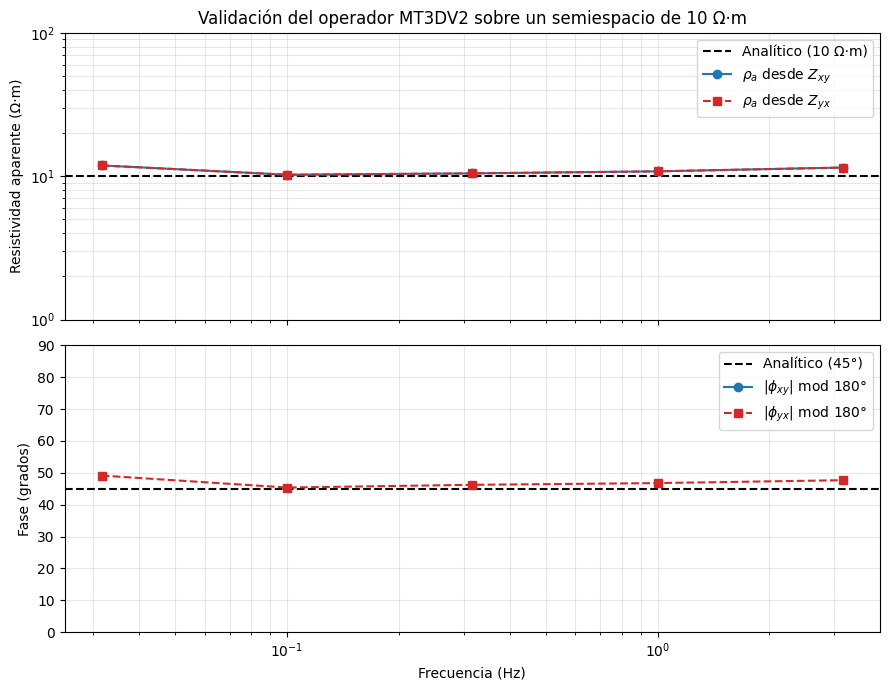

In [12]:
# Figura: validación contra el semiespacio analítico
fig, (ax_r, ax_p) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

ax_r.axhline(rho_semiespacio, color="k", ls="--", lw=1.5, label="Analítico (10 Ω·m)")
ax_r.plot(frequencies, rho_xy[0], "o-", color="tab:blue", label=r"$\rho_a$ desde $Z_{xy}$")
ax_r.plot(frequencies, rho_yx[0], "s--", color="tab:red", label=r"$\rho_a$ desde $Z_{yx}$")
ax_r.set_xscale("log"); ax_r.set_yscale("log")
ax_r.set_ylim(1, 100)
ax_r.set_ylabel("Resistividad aparente (Ω·m)")
ax_r.grid(True, which="both", alpha=0.3)
ax_r.legend()
ax_r.set_title("Validación del operador MT3D sobre un semiespacio de 10 Ω·m")

ax_p.axhline(45.0, color="k", ls="--", lw=1.5, label="Analítico (45°)")
ax_p.plot(frequencies, np.abs(phi_xy[0]) % 180, "o-", color="tab:blue", label=r"$|\phi_{xy}|$ mod 180°")
ax_p.plot(frequencies, np.abs(phi_yx[0]) % 180, "s--", color="tab:red", label=r"$|\phi_{yx}|$ mod 180°")
ax_p.set_xscale("log")
ax_p.set_ylim(0, 90)
ax_p.set_xlabel("Frecuencia (Hz)")
ax_p.set_ylabel("Fase (grados)")
ax_p.grid(True, which="both", alpha=0.3)
ax_p.legend()

plt.tight_layout()
plt.savefig("tutorial_validacion_semiespacio.png", dpi=200)
plt.show()

In [13]:
# El tipper de un modelo 1D debe ser CERO: sin estructura lateral no hay campo Hz.
print("Magnitud del tipper en el semiespacio (debe ser ~0):")
for j, f in enumerate(frequencies):
    print(f"  f = {f:8.4f} Hz  ->  |Tzx| = {np.abs(T_hs[0, j, 0]):.3e}   |Tzy| = {np.abs(T_hs[0, j, 1]):.3e}")
print()
print("Máximo |T| =", np.abs(T_hs).max(), " (nivel de ruido numérico: validación superada)")

Magnitud del tipper en el semiespacio (debe ser ~0):
  f =   0.0316 Hz  ->  |Tzx| = 2.080e-14   |Tzy| = 1.500e-14
  f =   0.1000 Hz  ->  |Tzx| = 2.372e-14   |Tzy| = 2.161e-14
  f =   0.3162 Hz  ->  |Tzx| = 2.271e-15   |Tzy| = 2.340e-15
  f =   1.0000 Hz  ->  |Tzx| = 1.546e-15   |Tzy| = 3.277e-15
  f =   3.1623 Hz  ->  |Tzx| = 1.767e-15   |Tzy| = 2.576e-15

Máximo |T| = 2.3719226886833863e-14  (nivel de ruido numérico: validación superada)


---

# Paso 9 — Un caso realmente 3D: bloque conductor + perfil de receptores

Ahora el uso típico: un cuerpo conductor enterrado y **varias estaciones** a lo largo de un perfil.
Cambian dos cosas respecto al ejemplo anterior:

1. `sigma` deja de ser homogéneo (se pinta un bloque de 1 Ω·m dentro del semiespacio de 10 Ω·m).
2. `receivers` pasa de 1 a 5 filas. **La malla y las frecuencias son las mismas**, así que el costo
   de cómputo es prácticamente el mismo: los receptores casi no cuestan.

Qué esperamos ver:

- La resistividad aparente **baja** en las estaciones sobre el bloque.
- El **tipper deja de ser cero**: el contraste lateral genera $H_z$. El tipper cambia de signo al
  cruzar el cuerpo y se anula justo encima de su centro.

In [14]:
# ------------------------------------------------------------------
# Paso 9a: modelo 3D con un bloque conductor
# ------------------------------------------------------------------
xc, yc, zc3 = mesh.cell_centers[:, 0], mesh.cell_centers[:, 1], mesh.cell_centers[:, 2]

sigma_3d = np.full(mesh.nC, sigma_semiespacio)   # semiespacio de fondo (10 Ohm*m)
sigma_3d[es_aire] = sigma_aire                   # aire

# Bloque conductor: 1 Ohm*m (1 S/m), desplazado hacia -x
bloque = (
    (xc >= -1600.0) & (xc <= 0.0) &
    (yc >= -1200.0) & (yc <= 1200.0) &
    (zc3 >= -2000.0) & (zc3 <= -500.0)
)
sigma_3d[bloque] = 1.0

print("celdas del bloque conductor:", int(bloque.sum()))
print("resistividades presentes [Ohm*m]:", np.round(1.0 / np.unique(sigma_3d[~es_aire]), 3))

# Perfil de 5 receptores a lo largo de x (y = 0), justo bajo la superficie
receivers_perfil = np.column_stack([
    np.array([-2400.0, -1200.0, 0.0, 1200.0, 2400.0]),
    np.zeros(5),
    np.full(5, -1.0),
])
print()
print("receivers_perfil.shape =", receivers_perfil.shape)
print(receivers_perfil)

celdas del bloque conductor: 144
resistividades presentes [Ohm*m]: [10.  1.]

receivers_perfil.shape = (5, 3)
[[-2.4e+03  0.0e+00 -1.0e+00]
 [-1.2e+03  0.0e+00 -1.0e+00]
 [ 0.0e+00  0.0e+00 -1.0e+00]
 [ 1.2e+03  0.0e+00 -1.0e+00]
 [ 2.4e+03  0.0e+00 -1.0e+00]]


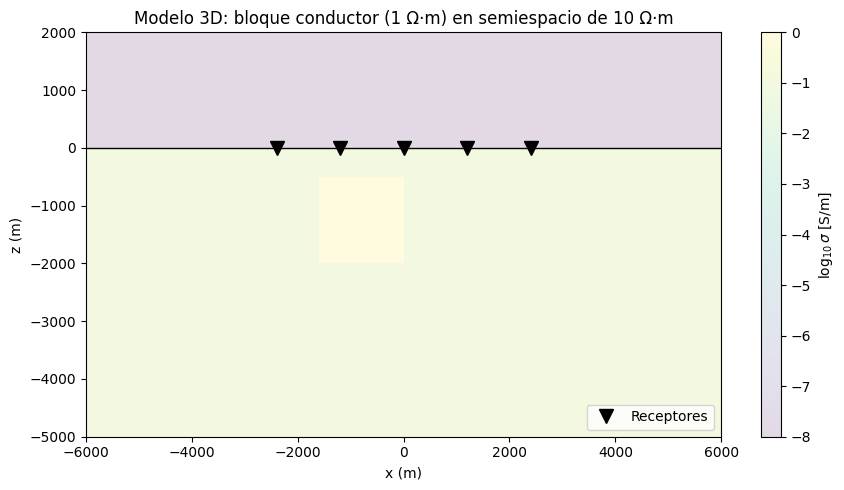

In [15]:
# Visualizar el modelo: corte vertical (normal a Y) con las estaciones marcadas
fig, ax = plt.subplots(figsize=(9, 5))
obj = mesh.plot_slice(np.log10(sigma_3d), normal="Y", ax=ax, grid=True, grid_opts={"alpha": 0.15})[0]
ax.plot(receivers_perfil[:, 0], receivers_perfil[:, 2], "v", color="k", ms=10, label="Receptores")
ax.axhline(0.0, color="k", lw=1.0)
ax.set_xlim(-6000, 6000)
ax.set_ylim(-5000, 2000)
ax.set_xlabel("x (m)"); ax.set_ylabel("z (m)")
ax.set_title("Modelo 3D: bloque conductor (1 Ω·m) en semiespacio de 10 Ω·m")
ax.legend(loc="lower right")
plt.colorbar(obj, ax=ax, label=r"$\log_{10}\sigma$ [S/m]")
plt.tight_layout()
plt.savefig("tutorial_modelo_3D.png", dpi=200)
plt.show()

In [16]:
# ------------------------------------------------------------------
# Paso 9b: forward del modelo 3D (misma llamada, otro sigma y más receptores)
# ------------------------------------------------------------------
t0 = time.time()

Z_3d, T_3d = compute_mt_impedance_tipper(mesh, sigma_3d, receivers_perfil, frequencies)

print()
print("Tiempo total: %.1f s" % (time.time() - t0))
print("Z:", Z_3d.shape, " T:", T_3d.shape)

Resolviendo para la frecuencia 0 de 5


calculando la impedancia en el receptor   0/5 at [-2.4e+03  0.0e+00 -1.0e+00], por favor espere :)
calculando la impedancia en el receptor   1/5 at [-1.2e+03  0.0e+00 -1.0e+00], por favor espere :)
calculando la impedancia en el receptor   2/5 at [ 0.  0. -1.], por favor espere :)
calculando la impedancia en el receptor   3/5 at [ 1.2e+03  0.0e+00 -1.0e+00], por favor espere :)
calculando la impedancia en el receptor   4/5 at [ 2.4e+03  0.0e+00 -1.0e+00], por favor espere :)
Resolviendo para la frecuencia 1 de 5


calculando la impedancia en el receptor   0/5 at [-2.4e+03  0.0e+00 -1.0e+00], por favor espere :)
calculando la impedancia en el receptor   1/5 at [-1.2e+03  0.0e+00 -1.0e+00], por favor espere :)
calculando la impedancia en el receptor   2/5 at [ 0.  0. -1.], por favor espere :)
calculando la impedancia en el receptor   3/5 at [ 1.2e+03  0.0e+00 -1.0e+00], por favor espere :)
calculando la impedancia en el receptor   4/5 at [ 2.4e+03  0.0e+00 -1.0e+00], por favor espere :)
Resolviendo para la frecuencia 2 de 5


calculando la impedancia en el receptor   0/5 at [-2.4e+03  0.0e+00 -1.0e+00], por favor espere :)
calculando la impedancia en el receptor   1/5 at [-1.2e+03  0.0e+00 -1.0e+00], por favor espere :)
calculando la impedancia en el receptor   2/5 at [ 0.  0. -1.], por favor espere :)
calculando la impedancia en el receptor   3/5 at [ 1.2e+03  0.0e+00 -1.0e+00], por favor espere :)
calculando la impedancia en el receptor   4/5 at [ 2.4e+03  0.0e+00 -1.0e+00], por favor espere :)
Resolviendo para la frecuencia 3 de 5


calculando la impedancia en el receptor   0/5 at [-2.4e+03  0.0e+00 -1.0e+00], por favor espere :)
calculando la impedancia en el receptor   1/5 at [-1.2e+03  0.0e+00 -1.0e+00], por favor espere :)
calculando la impedancia en el receptor   2/5 at [ 0.  0. -1.], por favor espere :)
calculando la impedancia en el receptor   3/5 at [ 1.2e+03  0.0e+00 -1.0e+00], por favor espere :)
calculando la impedancia en el receptor   4/5 at [ 2.4e+03  0.0e+00 -1.0e+00], por favor espere :)
Resolviendo para la frecuencia 4 de 5


calculando la impedancia en el receptor   0/5 at [-2.4e+03  0.0e+00 -1.0e+00], por favor espere :)
calculando la impedancia en el receptor   1/5 at [-1.2e+03  0.0e+00 -1.0e+00], por favor espere :)
calculando la impedancia en el receptor   2/5 at [ 0.  0. -1.], por favor espere :)
calculando la impedancia en el receptor   3/5 at [ 1.2e+03  0.0e+00 -1.0e+00], por favor espere :)
calculando la impedancia en el receptor   4/5 at [ 2.4e+03  0.0e+00 -1.0e+00], por favor espere :)

Tiempo total: 662.6 s
Z: (5, 5, 2, 2)  T: (5, 5, 2)


In [17]:
# Resistividad aparente y fase por estación
rho_xy_3d = apparent_resistivity(Z_3d[:, :, 0, 1], frequencies)
rho_yx_3d = apparent_resistivity(Z_3d[:, :, 1, 0], frequencies)
phi_yx_3d = phase_deg(Z_3d[:, :, 1, 0])

print("Resistividad aparente rho_xy [Ohm*m] (filas = receptor, columnas = frecuencia):")
print(f"{'x [m]':>8}", "".join(f"{f:11.4f}" for f in frequencies))
print("-" * (8 + 11 * len(frequencies)))
for i, r in enumerate(receivers_perfil):
    print(f"{r[0]:8.0f}", "".join(f"{v:11.2f}" for v in rho_xy_3d[i]))

Resistividad aparente rho_xy [Ohm*m] (filas = receptor, columnas = frecuencia):
   x [m]      0.0316     0.1000     0.3162     1.0000     3.1623
---------------------------------------------------------------
   -2400       14.18      11.70      10.79      10.14      11.06
   -1200        3.02       2.96       3.63       4.91       7.59
       0        7.65       6.55       6.58       7.05       9.03
    1200       14.78      12.09      11.18      10.54      11.36
    2400       13.25      11.10      10.66      10.66      11.48


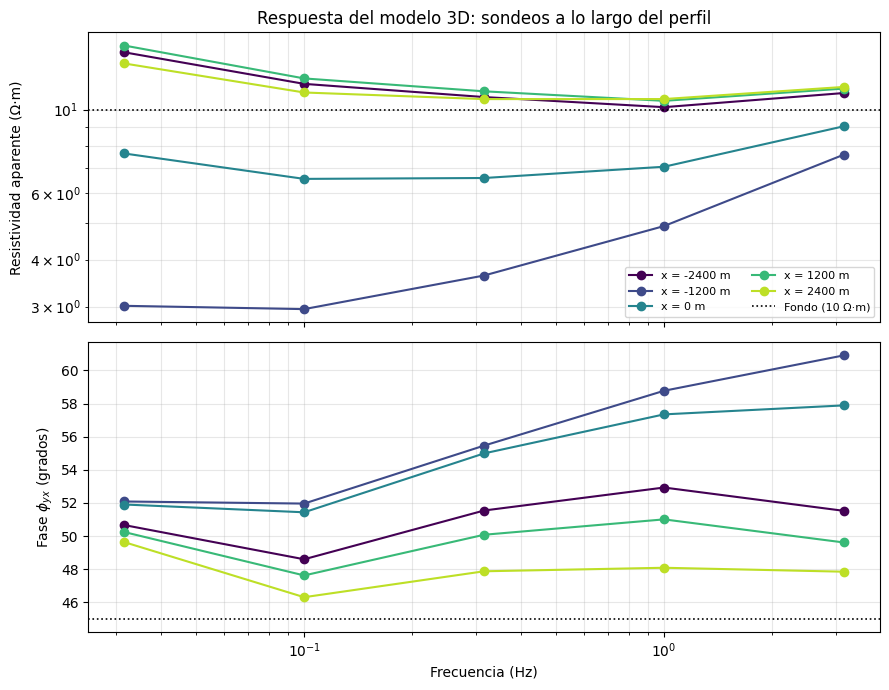

In [18]:
# Curvas de sondeo: una línea por estación
fig, (ax_r, ax_p) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
colores = plt.cm.viridis(np.linspace(0, 0.9, len(receivers_perfil)))

for i, r in enumerate(receivers_perfil):
    ax_r.plot(frequencies, rho_xy_3d[i], "o-", color=colores[i], label=f"x = {r[0]:.0f} m")
    ax_p.plot(frequencies, phi_yx_3d[i], "o-", color=colores[i])

ax_r.axhline(rho_semiespacio, color="k", ls=":", lw=1.2, label="Fondo (10 Ω·m)")
ax_r.set_xscale("log"); ax_r.set_yscale("log")
ax_r.set_ylabel("Resistividad aparente (Ω·m)")
ax_r.grid(True, which="both", alpha=0.3)
ax_r.legend(fontsize=8, ncol=2)
ax_r.set_title("Respuesta del modelo 3D: sondeos a lo largo del perfil")

ax_p.axhline(45.0, color="k", ls=":", lw=1.2)
ax_p.set_xscale("log")
ax_p.set_xlabel("Frecuencia (Hz)")
ax_p.set_ylabel(r"Fase $\phi_{yx}$ (grados)")
ax_p.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig("tutorial_respuesta_3D.png", dpi=200)
plt.show()

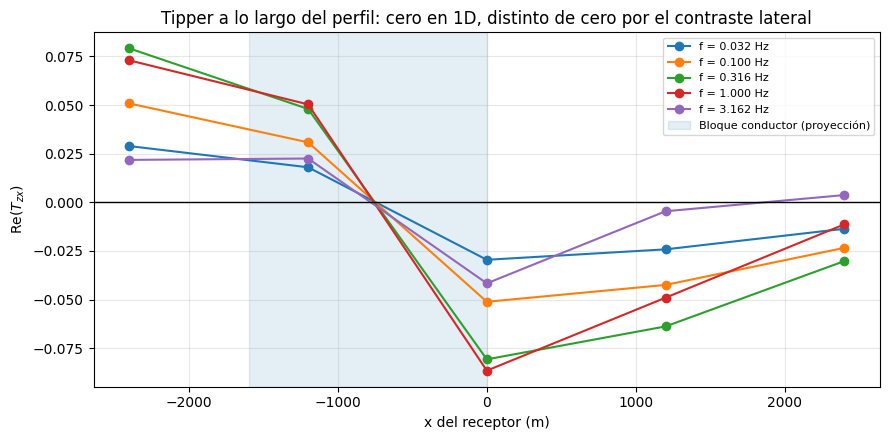

Máx |T| en el modelo 3D: 0.08956179752455624  (frente a ~1e-15 en el semiespacio)


In [19]:
# El tipper delata la estructura lateral: parte real de Tzx a lo largo del perfil
fig, ax = plt.subplots(figsize=(9, 4.5))
for j, f in enumerate(frequencies):
    ax.plot(receivers_perfil[:, 0], np.real(T_3d[:, j, 0]), "o-", label=f"f = {f:.3f} Hz")

ax.axvspan(-1600, 0, color="tab:blue", alpha=0.12, label="Bloque conductor (proyección)")
ax.axhline(0.0, color="k", lw=1.0)
ax.set_xlabel("x del receptor (m)")
ax.set_ylabel(r"Re($T_{zx}$)")
ax.set_title("Tipper a lo largo del perfil: cero en 1D, distinto de cero por el contraste lateral")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("tutorial_tipper_3D.png", dpi=200)
plt.show()

print("Máx |T| en el modelo 3D:", np.abs(T_3d).max(), " (frente a ~1e-15 en el semiespacio)")

---

# Paso 10 — Qué hace el operador por dentro, línea por línea

Ya sabemos *usarlo*. Esta sección abre la caja negra: recorre `Forward/MT3D.py` en el mismo orden
en que se ejecuta. Es la parte que hay que entender para modificarlo o para depurar resultados
extraños.

### A. Preparación (una sola vez, fuera del bucle de frecuencias)

```python
if mu is None:
    mu = mu0 * np.ones(mesh.nC)          # permeabilidad por defecto

receivers = np.atleast_2d(receivers)     # acepta un receptor suelto [x, y, z]

C = mesh.edge_curl                       # operador rotacional discreto: aristas -> caras
bc_mask, _, _ = _prepare_bc_masks(mesh)  # aristas del TOPE de la malla (frontera de Dirichlet)

below_surface = mesh.cell_centers[:, 2] <= 0   # criterio tierra/aire  (¡z = 0 fijo!)
sigma_background = 1e-2                        # conductividad de referencia (¡fija!)

mu_faces = mesh.aveCC2F @ mu             # mu promediado de centros de celda a caras
```

- `mesh.edge_curl` (`C`) es el rotacional discreto: toma el campo E definido en **aristas** y lo
  lleva a **caras**. Es la pieza central del método de volúmenes finitos de `discretize`.
- `_prepare_bc_masks` (en `Forward/utils.py`) marca las aristas x e y del **techo** de la malla.
  Ahí se impone la onda plana incidente: el campo secundario vale cero (Dirichlet homogéneo).

```python
Pex = mesh.get_interpolation_matrix(receivers, "Ex")   # E en aristas x -> receptores
Pey = mesh.get_interpolation_matrix(receivers, "Ey")
Pfx = mesh.get_interpolation_matrix(receivers, "Fx")   # H en caras -> receptores
Pfy = mesh.get_interpolation_matrix(receivers, "Fy")
Pfz = mesh.get_interpolation_matrix(receivers, "Fz")
```

Estas matrices dispersas interpolan del *staggered grid* a la posición exacta de la estación.
Se construyen **una vez** y se reutilizan en todas las frecuencias: por eso agregar receptores es
casi gratis.

### B. Bucle sobre frecuencias — ensamblaje del sistema

```python
omega = 2 * np.pi * freq
Msigma  = mesh.get_edge_inner_product(sigma)      # matriz de masa de sigma (aristas)
Mmu_inv = mesh.get_face_inner_product(1 / mu)     # matriz de masa de 1/mu (caras)
A = C.T @ Mmu_inv @ C + 1j * omega * Msigma       # sistema curl-curl
```

`A` es la discretización de $\nabla\times(\mu^{-1}\nabla\times) + i\omega\sigma$.
Es dispersa, compleja, simétrica, y **de tamaño `mesh.nE` × `mesh.nE`**: por eso el número de
aristas manda en el costo, no el número de celdas.

### C. Campo primario y factorización

```python
primary_ex, primary_ey = _primary_fields(mesh, omega, sigma_background)
solver_data = _prepare_solver(A, bc_mask)         # <-- factorización LU (lo caro)
```

`_primary_fields` construye la onda plana analítica $e^{kz}$ del semiespacio de referencia, para
las dos polarizaciones. `_prepare_solver` separa las incógnitas libres de las fijadas por la
frontera y factoriza con `scipy.sparse.linalg.factorized`. **Una sola factorización sirve para las
dos polarizaciones.**

### D. Fuente y solución del campo secundario

```python
delta_sigma = np.zeros(mesh.nC)
delta_sigma[below_surface] = sigma[below_surface] - sigma_background
Mdelta_sigma = mesh.get_edge_inner_product(delta_sigma)

rhs_ex   = -1j * omega * (Mdelta_sigma @ primary_ex)
ex_total = primary_ex + _solve_secondary(rhs_ex, solver_data)   # polarización Ex

rhs_ey   = -1j * omega * (Mdelta_sigma @ primary_ey)
ey_total = primary_ey + _solve_secondary(rhs_ey, solver_data)   # polarización Ey
```

Este es el corazón del esquema de campo secundario. Nótese que `delta_sigma` es **cero en el aire**:
el contraste solo se evalúa donde `below_surface` es verdadero.

### E. De E a H (ley de Faraday)

```python
B_from_Ex = -(1 / (1j * omega)) * (C @ ex_total)
H_from_Ex = B_from_Ex / mu_faces
Hx_from_Ex = H_from_Ex[:nFx]                      # bloques del vector de caras
Hy_from_Ex = H_from_Ex[nFx : nFx + nFy]
Hz_from_Ex = H_from_Ex[nFx + nFy :]
```

El vector de caras está ordenado como `[caras-x | caras-y | caras-z]`; de ahí los cortes.

### F. Impedancias y tipper en cada receptor

```python
Zxy = Ex_val / Hy_val_ex        # de la polarización Ex
Zyx = Ey_val / Hx_val_ey        # de la polarización Ey
Zxx = Ex_val / Hx_val_ex
Zyy = Ey_val / Hy_val_ey

A_mat = [[Hx_ex, Hy_ex],
         [Hx_ey, Hy_ey]]        # las dos polarizaciones como sistema 2x2
b_vec = [Hz_ex, Hz_ey]
T[ir, ifreq, :] = np.linalg.solve(A_mat, b_vec)   # [Tzx, Tzy]
```

El tipper sí se obtiene resolviendo el sistema 2×2 que combina ambas polarizaciones, con
`try/except np.linalg.LinAlgError` que devuelve `NaN` si la matriz está mal condicionada
(por eso el operador "descarta" receptores problemáticos en vez de fallar).

> **Nota técnica sobre `Z`.** Las cuatro componentes se calculan como **cocientes directos**
> $E_i/H_j$ dentro de cada polarización, no resolviendo el sistema 2×2
> $\mathbf{E} = \mathbf{Z}\,\mathbf{H}$ con las dos polarizaciones a la vez (que es lo que sí se
> hace para el tipper). Para modelos 1D y 2D coincide; en modelos 3D con acoplamiento fuerte entre
> polarizaciones, $Z_{xy}$ y $Z_{yx}$ obtenidos así son una aproximación, y $Z_{xx}$, $Z_{yy}$ no
> son las componentes diagonales del tensor MT estándar. Es la razón por la que las comparaciones
> con SimPEG (`MT_Toy6`) se hacen sobre $Z_{xy}$ y $Z_{yx}$.

### G. Resumen del costo

| Aumentar… | Efecto en el costo |
|---|---|
| Frecuencias | **Lineal y caro**: una factorización LU nueva por frecuencia |
| Receptores | Casi gratis: solo productos matriz-vector dispersos |
| Celdas de la malla | Muy fuerte (la LU 3D escala peor que lineal) |
| Polarizaciones | Ya están las dos incluidas; comparten factorización |

---

# Paso 11 — Guardar resultados, errores frecuentes y lista de chequeo

## 11.1 Guardar y volver a cargar

La convención del repositorio (ver `Examples/Modelling/Toys/MT_ToyN/`) es guardar `Z` y `T` como
`.npy`, para poder comparar corridas sin recalcular.

In [20]:
# ------------------------------------------------------------------
# Paso 11: guardar y recargar resultados
# ------------------------------------------------------------------
guardar = True   # ponlo en False si no quieres escribir archivos

if guardar:
    np.save("tutorial_impedance_3D.npy", Z_3d)
    np.save("tutorial_tipper_3D.npy", T_3d)
    np.save("tutorial_receivers.npy", receivers_perfil)
    np.save("tutorial_frequencies.npy", frequencies)
    print("Guardado: tutorial_impedance_3D.npy, tutorial_tipper_3D.npy, "
          "tutorial_receivers.npy, tutorial_frequencies.npy")

# Recarga (así se retoma un análisis sin repetir el forward, que es lo caro)
Z_cargado = np.load("tutorial_impedance_3D.npy")
print("Recargado Z:", Z_cargado.shape, "| ¿idéntico?", np.allclose(Z_cargado, Z_3d))

Guardado: tutorial_impedance_3D.npy, tutorial_tipper_3D.npy, tutorial_receivers.npy, tutorial_frequencies.npy
Recargado Z: (5, 5, 2, 2) | ¿idéntico? True


## 11.2 Errores frecuentes y cómo se ven

| Síntoma | Causa probable | Solución |
|---|---|---|
| `ValueError` al construir `M_sigma`, o resultados absurdos | `sigma` no tiene longitud `mesh.nC` | `assert sigma.shape == (mesh.nC,)` |
| Campos enormes / `inf` / `nan` | Alguna celda con `sigma = 0` (típicamente el aire) | Usar `1e-8`, nunca `0` |
| $\rho_a$ correcto a alta frecuencia y disparatado a baja | Dominio demasiado pequeño para el skin depth bajo | Más padding, más profundidad |
| $\rho_a$ correcto a baja frecuencia y disparatado a alta | Celdas demasiado gruesas cerca de la superficie | Refinar `dz` en el núcleo |
| Todo el modelo responde como 100 Ω·m | La superficie no está en $z = 0$: `below_surface` clasificó mal y $\Delta\sigma = 0$ | Alinear la malla para que $z=0$ sea un nodo |
| Tipper = `NaN` en algunas estaciones | La matriz 2×2 de $H$ quedó mal condicionada | Revisar la posición del receptor (muy cerca de un borde o de un contraste extremo) |
| Es lentísimo | Demasiadas frecuencias o malla muy grande | Reducir frecuencias para prototipar; refinar solo al final |
| `ModuleNotFoundError: Forward` | `sys.path` mal puesto | Ajustar el número de `../` a la ubicación del cuaderno |
| `ModuleNotFoundError: torch` / `geoana` | `Forward/utils.py` los importa para las utilidades de gravimetría y magnetometría | Instalarlos en el entorno |

## 11.3 Lista de chequeo antes de cada corrida

1. `sigma.shape == (mesh.nC,)` y sin ceros.
2. Aire definido como $z > 0$ con `1e-8`; superficie alineada con $z = 0$.
3. Receptores dentro de la malla, con $z \lesssim 0$.
4. Tabla de skin depth revisada: celdas finas para la frecuencia alta, dominio grande para la baja.
5. Antes de correr el modelo de interés, **correr un semiespacio equivalente** y confirmar
   $\rho_a \approx \rho$ y $|\phi| \approx 45^\circ$. Esa única prueba detecta casi todos los
   errores de malla.

## 11.4 Plantilla mínima para copiar y pegar

```python
import sys, os
import numpy as np
from discretize import TensorMesh

sys.path.append(os.path.abspath("../../"))          # ajustar a tu ubicación
from Forward.MT3D import compute_mt_impedance_tipper
from Forward.utils import apparent_resistivity, phase_deg

mesh   = ...                                        # TensorMesh con z = 0 en la superficie
sigma  = ...                                        # array (mesh.nC,), aire = 1e-8
rx     = np.array([[0.0, 0.0, -1.0]])               # (n_rec, 3)
freqs  = np.logspace(-3, 2, 20)                     # (n_freq,)

Z, T = compute_mt_impedance_tipper(mesh, sigma, rx, freqs)

rho_xy = apparent_resistivity(Z[:, :, 0, 1], freqs)
phi_xy = phase_deg(Z[:, :, 0, 1])
Tzx, Tzy = T[:, :, 0], T[:, :, 1]
```

## 11.5 Dónde seguir

| Quiero… | Ir a |
|---|---|
| Ver el operador aplicado a modelos sintéticos ya armados | `Examples/Modelling/Toys/MT_Toy3` … `MT_Toy6` |
| Comparar contra SimPEG | `Examples/Modelling/Toys/MT_Toy6/MT_ModelToy6_SimPEG.ipynb` |
| Cómo se construyen las mallas y modelos de los Toys | `models/Toy3/` … `models/Toy6/` |
| Obtener los campos E y H completos (no solo Z y T) | `Forward/MT3DE.py`, `Forward/MT3DZ.py` |
| Gradiente, función de costo e inversión | `Forward/utils.py`: `cost_and_gradient`, `line_search` |

---

**Resumen en una frase:** `compute_mt_impedance_tipper(mesh, sigma, receivers, frequencies)`
resuelve la ecuación curl–curl en formulación de campo secundario para dos polarizaciones por
frecuencia y devuelve `Z` de forma `(n_rec, n_freq, 2, 2)` y `T` de forma `(n_rec, n_freq, 2)`;
todo lo demás es diseñar bien la malla y verificar contra un semiespacio.